# OPS-SAT-AD — Exploración de `segments.csv`

Objetivo: entender la estructura cruda de las series temporales antes de diseñar el modelo Transformer.

**Dataset:** OPS-SAT-AD, KP Labs / ESA. Licencia CC-BY 4.0.  
**Referencia:** Ruszczak et al., Nature Scientific Data 2025. DOI 10.1038/s41597-025-05035-3

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = Path('../reference/data/segments.csv')
seg = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
print(f'Loaded {len(seg):,} rows, {seg.segment.nunique()} segments')

Loaded 303,493 rows, 2123 segments


## 1. Estructura básica

In [2]:
print('Shape:', seg.shape)
print('\nDtypes:')
print(seg.dtypes)
print('\nPrimeras filas:')
seg.head()

Shape: (303493, 8)

Dtypes:
channel                   object
timestamp    datetime64[ns, UTC]
value                    float64
label                     object
sampling                   int64
anomaly                    int64
segment                    int64
train                      int64
dtype: object

Primeras filas:


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-06-01 23:42:54+00:00,-0.000021,anomaly,1,1,1,1
1,CADC0872,2022-06-01 23:42:55+00:00,-0.000021,anomaly,1,1,1,1
2,CADC0872,2022-06-01 23:42:56+00:00,-0.000021,anomaly,1,1,1,1
3,CADC0872,2022-06-01 23:42:57+00:00,-0.000021,anomaly,1,1,1,1
4,CADC0872,2022-06-01 23:42:58+00:00,-0.000021,anomaly,1,1,1,1


## 2. ¿Cuántos segmentos hay y cuántos puntos tiene cada uno?

In [3]:
seg_stats = seg.groupby('segment').agg(
    n_points  =('value',     'count'),
    channel   =('channel',   'first'),
    sampling  =('sampling',  'first'),
    anomaly   =('anomaly',   'first'),
    train     =('train',     'first'),
    duration_s=('timestamp', lambda x: (x.max()-x.min()).total_seconds())
).reset_index()

print(f"Total segmentos : {len(seg_stats)}")
print(f"  Train         : {(seg_stats.train==1).sum()}")
print(f"  Test          : {(seg_stats.train==0).sum()}")
print(f"  Anomaly       : {(seg_stats.anomaly==1).sum()} ({(seg_stats.anomaly==1).mean():.1%})")
print(f"  Normal        : {(seg_stats.anomaly==0).sum()} ({(seg_stats.anomaly==0).mean():.1%})")
print()
print('Puntos por segmento:')
print(seg_stats['n_points'].describe().round(1).to_string())

Total segmentos : 2123
  Train         : 1594
  Test          : 529
  Anomaly       : 434 (20.4%)
  Normal        : 1689 (79.6%)

Puntos por segmento:
count    2123.0
mean      143.0
std       152.3
min         8.0
25%        40.0
50%        70.0
75%       201.0
max      1040.0


/var/folders/21/r8gdylh55ts2fv9w1bz3j77c0000gn/T/ipykernel_78019/1502963032.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_bp, labels=['Normal', 'Anomaly'], patch_artist=True,


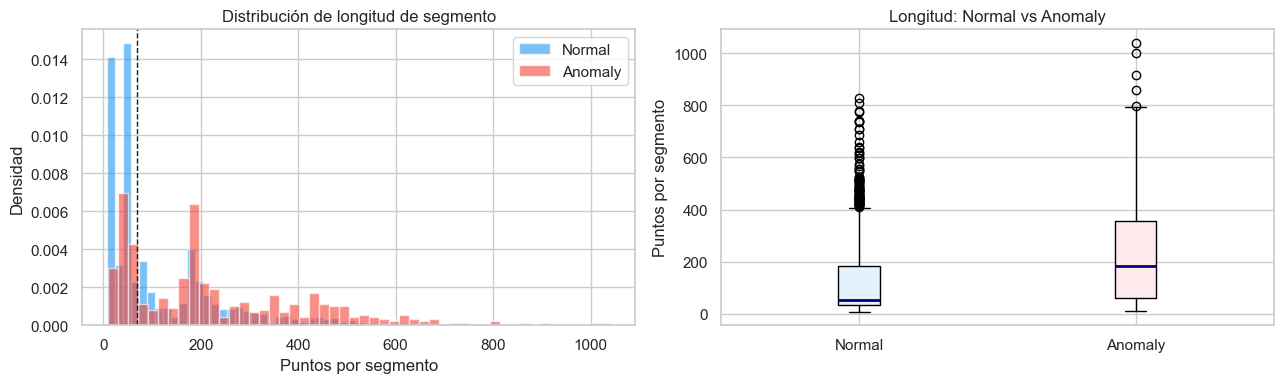

Mediana normal: 54.0
Mediana anomaly: 184.5


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de n_points
for ax, group, color, label in [
    (axes[0], seg_stats[seg_stats.anomaly==0], '#2196F3', 'Normal'),
    (axes[0], seg_stats[seg_stats.anomaly==1], '#F44336', 'Anomaly'),
]:
    ax.hist(group['n_points'], bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Puntos por segmento')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de longitud de segmento')
axes[0].legend()
axes[0].axvline(seg_stats['n_points'].median(), color='k', ls='--', lw=1, label=f'Mediana={seg_stats["n_points"].median():.0f}')

# Boxplot por anomaly
data_bp = [seg_stats[seg_stats.anomaly==0]['n_points'], seg_stats[seg_stats.anomaly==1]['n_points']]
bp = axes[1].boxplot(data_bp, labels=['Normal', 'Anomaly'], patch_artist=True,
                     boxprops=dict(facecolor='#E3F2FD'), medianprops=dict(color='navy', lw=2))
bp['boxes'][1].set_facecolor('#FFEBEE')
axes[1].set_ylabel('Puntos por segmento')
axes[1].set_title('Longitud: Normal vs Anomaly')

plt.tight_layout()
plt.savefig('../data/processed/fig1_segment_lengths.png', dpi=120, bbox_inches='tight')
plt.show()
print('Mediana normal:', seg_stats[seg_stats.anomaly==0]['n_points'].median())
print('Mediana anomaly:', seg_stats[seg_stats.anomaly==1]['n_points'].median())

## 3. Frecuencia de muestreo (sampling rate)

In [5]:
sr = seg.groupby('sampling').agg(
    n_rows     =('value',   'count'),
    n_segments =('segment', 'nunique'),
).reset_index()
sr['pct_segments'] = sr['n_segments'] / sr['n_segments'].sum()
print(sr.to_string(index=False))
print()
print('Interpretación:')
print('  sampling=1 → 1 punto/segundo (1 Hz)')
print('  sampling=5 → 1 punto cada 5 segundos (0.2 Hz)')
print()
# Stats por sampling rate
print(seg_stats.groupby('sampling')[['n_points','duration_s']].describe().round(1).to_string())

 sampling  n_rows  n_segments  pct_segments
        1  237165         793      0.373528
        5   66328        1330      0.626472

Interpretación:
  sampling=1 → 1 punto/segundo (1 Hz)
  sampling=5 → 1 punto cada 5 segundos (0.2 Hz)

         n_points                                                   duration_s                                                  
            count   mean    std    min    25%    50%    75%     max      count   mean    std    min    25%    50%    75%     max
sampling                                                                                                                        
1           793.0  299.1  145.5  105.0  189.0  239.0  376.0  1040.0      793.0  298.1  145.5  104.0  188.0  238.0  375.0  1039.0
5          1330.0   49.9   35.0    8.0   21.0   45.0   58.0   268.0     1330.0  246.3  176.1   35.0  100.0  220.0  290.0  1335.0


> **Implicación para el modelo:** los segmentos con `sampling=1` tienen ~6x más puntos que `sampling=5` para duraciones similares. El modelo debe recibir longitud fija → hay que truncar/padear o normalizar por duración temporal.

## 4. Canales: ¿cuántos hay y cómo se distribuyen?

In [6]:
ch_stats = seg.groupby('channel').agg(
    n_rows        =('value',   'count'),
    n_segments    =('segment', 'nunique'),
    anomaly_rate  =('anomaly', 'mean'),
    sampling_mode =('sampling', lambda x: x.mode()[0]),
    value_mean    =('value',   'mean'),
    value_std     =('value',   'std'),
).reset_index().sort_values('n_segments', ascending=False)

ch_stats['anomaly_rate'] = ch_stats['anomaly_rate'].round(3)
print(f'Canales únicos: {len(ch_stats)}')
print()
print(ch_stats.to_string(index=False))

Canales únicos: 9

 channel  n_rows  n_segments  anomaly_rate  sampling_mode    value_mean  value_std
CADC0873   68289         593         0.329              1 -1.132248e-06   0.000021
CADC0872   66819         546         0.365              1  9.843982e-07   0.000021
CADC0888   11640         252         0.237              5  2.654264e-01   0.337997
CADC0892   49782         211         0.145              1  2.545815e-01   0.331502
CADC0874   58719         194         0.604              1  3.231948e-06   0.000020
CADC0884   11810         158         0.000              5  4.707211e-01   0.391373
CADC0894   35512         144         0.212              1  1.135705e-01   0.208981
CADC0890     549          14         0.732              5  2.421779e-01   0.327383
CADC0886     373          11         0.233              5  1.831110e-01   0.205464


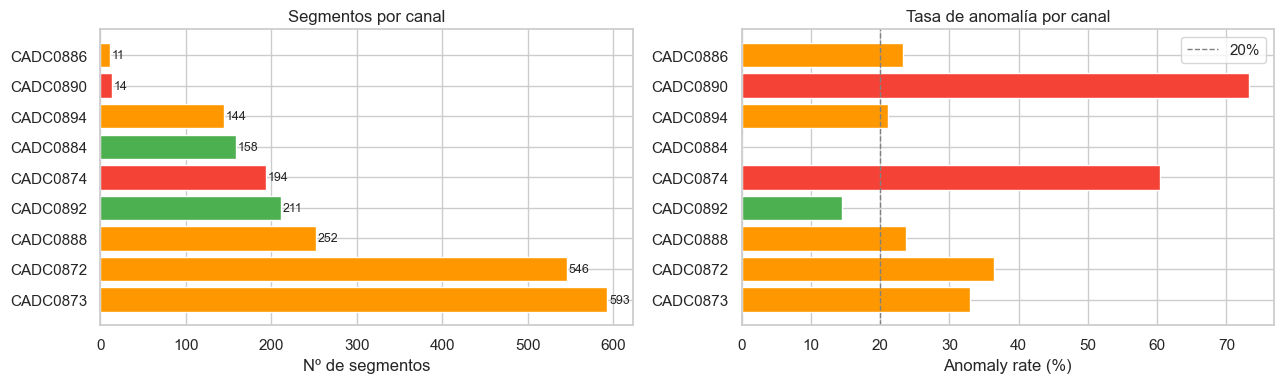

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Segmentos por canal
colors = ['#F44336' if r > 0.5 else '#FF9800' if r > 0.2 else '#4CAF50'
          for r in ch_stats['anomaly_rate']]
axes[0].barh(ch_stats['channel'], ch_stats['n_segments'], color=colors)
axes[0].set_xlabel('Nº de segmentos')
axes[0].set_title('Segmentos por canal')
for i, (_, row) in enumerate(ch_stats.iterrows()):
    axes[0].text(row['n_segments']+2, i, f'{row["n_segments"]}', va='center', fontsize=9)

# Anomaly rate por canal
bar_colors = ['#F44336' if r > 0.5 else '#FF9800' if r > 0.2 else '#4CAF50'
              for r in ch_stats['anomaly_rate']]
bars = axes[1].barh(ch_stats['channel'], ch_stats['anomaly_rate']*100, color=bar_colors)
axes[1].set_xlabel('Anomaly rate (%)')
axes[1].set_title('Tasa de anomalía por canal')
axes[1].axvline(20, color='gray', ls='--', lw=1, label='20%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig2_channel_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Duración media y distribución: normales vs anómalos

In [8]:
print('Duración (segundos) por clase:')
print(seg_stats.groupby('anomaly')['duration_s'].describe().round(1).rename(index={0:'Normal',1:'Anomaly'}).to_string())
print()
print('Longitud (puntos) por clase:')
print(seg_stats.groupby('anomaly')['n_points'].describe().round(1).rename(index={0:'Normal',1:'Anomaly'}).to_string())

Duración (segundos) por clase:
          count   mean    std   min    25%    50%    75%     max
anomaly                                                         
Normal   1689.0  251.0  159.5  35.0  160.0  220.0  300.0  1335.0
Anomaly   434.0  322.4  183.5  45.0  187.2  266.0  429.8  1115.0

Longitud (puntos) por clase:
          count   mean    std   min   25%    50%    75%     max
anomaly                                                        
Normal   1689.0  120.3  131.7   8.0  35.0   54.0  184.0   827.0
Anomaly   434.0  231.0  190.7  10.0  61.2  184.5  354.5  1040.0


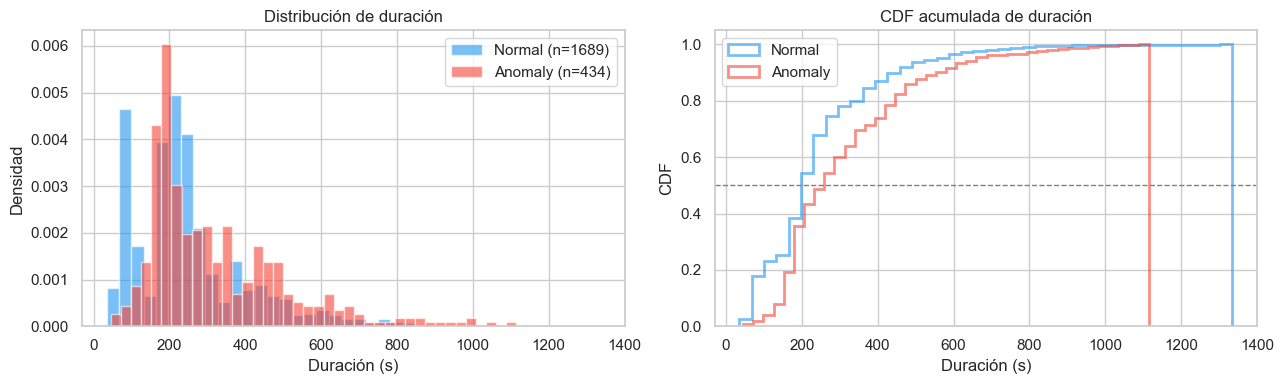

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for anomaly, label, color in [(0,'Normal','#2196F3'), (1,'Anomaly','#F44336')]:
    data = seg_stats[seg_stats.anomaly==anomaly]['duration_s']
    axes[0].hist(data, bins=40, alpha=0.6, color=color, label=f'{label} (n={len(data)})', density=True)
    axes[1].hist(data, bins=40, alpha=0.6, color=color, label=f'{label}', density=True,
                 cumulative=True, histtype='step', lw=2)

axes[0].set_xlabel('Duración (s)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de duración')
axes[0].legend()

axes[1].set_xlabel('Duración (s)')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF acumulada de duración')
axes[1].legend()
axes[1].axhline(0.5, color='gray', ls='--', lw=1)

plt.tight_layout()
plt.savefig('../data/processed/fig3_duration_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Visualización de series temporales: normales vs anómalos

In [10]:
# Seleccionar ejemplos con longitud media para visualización clara
# Normal: sampling=1, 100-250 puntos
# Anomaly: sampling=1, 150-350 puntos

normal_ids = seg_stats[
    (seg_stats.anomaly==0) & (seg_stats.sampling==1) &
    (seg_stats.n_points.between(100,250))
]['segment'].values[:3]

anomaly_ids = seg_stats[
    (seg_stats.anomaly==1) & (seg_stats.sampling==1) &
    (seg_stats.n_points.between(150,350))
]['segment'].values[:3]

print('Normal segments:', normal_ids)
print('Anomaly segments:', anomaly_ids)

Normal segments: [11 12 14]
Anomaly segments: [ 1  4 13]


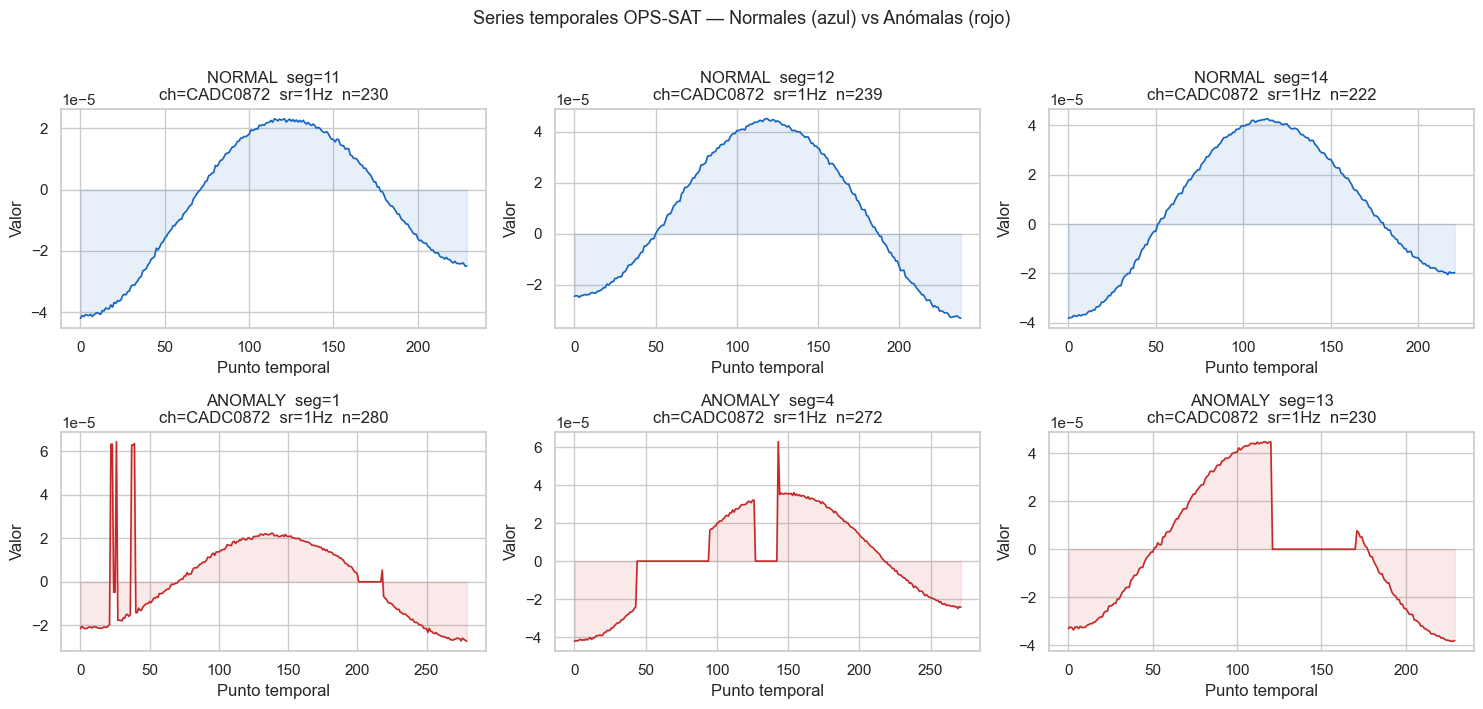

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Series temporales OPS-SAT — Normales (azul) vs Anómalas (rojo)', fontsize=13, y=1.01)

for col, seg_id in enumerate(normal_ids):
    data = seg[seg.segment==seg_id].sort_values('timestamp')
    ch   = data.channel.iloc[0]
    sr   = data.sampling.iloc[0]
    axes[0, col].plot(data['value'].values, color='#1565C0', lw=1.2)
    axes[0, col].set_title(f'NORMAL  seg={seg_id}\nch={ch}  sr={sr}Hz  n={len(data)}')
    axes[0, col].set_xlabel('Punto temporal')
    axes[0, col].set_ylabel('Valor')
    axes[0, col].fill_between(range(len(data)), data['value'].values, alpha=0.1, color='#1565C0')

for col, seg_id in enumerate(anomaly_ids):
    data = seg[seg.segment==seg_id].sort_values('timestamp')
    ch   = data.channel.iloc[0]
    sr   = data.sampling.iloc[0]
    axes[1, col].plot(data['value'].values, color='#C62828', lw=1.2)
    axes[1, col].set_title(f'ANOMALY  seg={seg_id}\nch={ch}  sr={sr}Hz  n={len(data)}')
    axes[1, col].set_xlabel('Punto temporal')
    axes[1, col].set_ylabel('Valor')
    axes[1, col].fill_between(range(len(data)), data['value'].values, alpha=0.1, color='#C62828')

plt.tight_layout()
plt.savefig('../data/processed/fig4_series_examples.png', dpi=120, bbox_inches='tight')
plt.show()

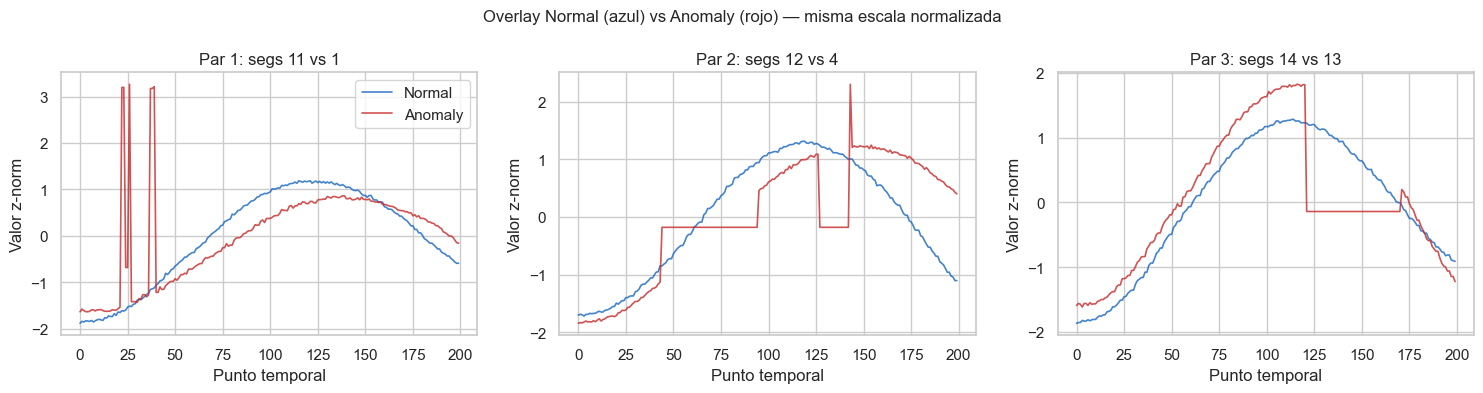

In [12]:
# Comparación overlay: normalizado para ver diferencia de forma
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Overlay Normal (azul) vs Anomaly (rojo) — misma escala normalizada', fontsize=12)

for col in range(3):
    norm_data   = seg[seg.segment==normal_ids[col]].sort_values('timestamp')['value'].values
    anom_data   = seg[seg.segment==anomaly_ids[col]].sort_values('timestamp')['value'].values
    # Z-score normalize
    def znorm(x):
        return (x - x.mean()) / (x.std() + 1e-8)
    # Truncate to same length for overlay
    L = min(len(norm_data), len(anom_data), 200)
    axes[col].plot(znorm(norm_data[:L]), color='#1565C0', alpha=0.8, lw=1.2, label='Normal')
    axes[col].plot(znorm(anom_data[:L]), color='#C62828', alpha=0.8, lw=1.2, label='Anomaly')
    axes[col].set_title(f'Par {col+1}: segs {normal_ids[col]} vs {anomaly_ids[col]}')
    axes[col].set_xlabel('Punto temporal')
    axes[col].set_ylabel('Valor z-norm')
    if col == 0:
        axes[col].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig5_overlay_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Estadísticas de valor por canal

In [13]:
# Rango de valores por canal
val_stats = seg.groupby(['channel','anomaly'])['value'].agg(['mean','std','min','max']).round(6)
val_stats.index = val_stats.index.set_levels(['Normal','Anomaly'], level=1)
print(val_stats.to_string())

                      mean       std       min       max
channel  anomaly                                        
CADC0872 Normal   0.000001  0.000022 -0.000050  0.000050
         Anomaly  0.000001  0.000020 -0.000088  0.000065
CADC0873 Normal  -0.000001  0.000022 -0.000052  0.000049
         Anomaly -0.000002  0.000019 -0.000101  0.000060
CADC0874 Normal   0.000004  0.000021 -0.000048  0.000048
         Anomaly  0.000003  0.000019 -0.000048  0.000101
CADC0884 Normal   0.470721  0.391373  0.000000  1.570800
CADC0886 Normal   0.178420  0.224700  0.000000  0.721150
         Anomaly  0.198532  0.122355  0.000000  0.402829
CADC0888 Normal   0.287213  0.358295  0.000000  1.301890
         Anomaly  0.195129  0.249387  0.000000  1.233020
CADC0890 Normal   0.369706  0.385166  0.000000  1.164130
         Anomaly  0.195545  0.290369  0.000000  1.119730
CADC0892 Normal   0.272371  0.345272  0.000000  1.570800
         Anomaly  0.149947  0.205617  0.000000  1.056480
CADC0894 Normal   0.126711  0.2

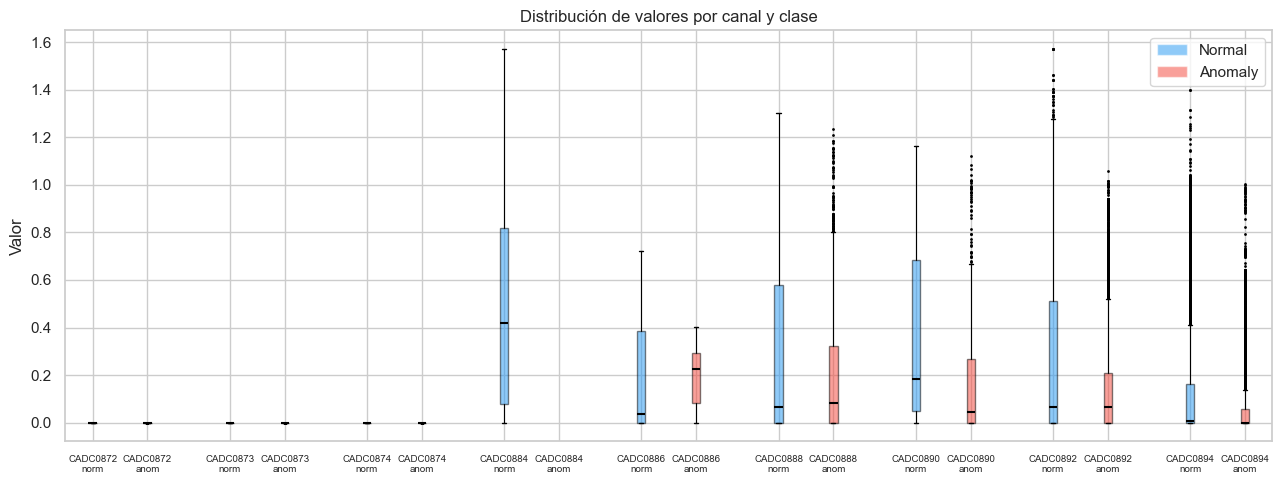

In [14]:
# Boxplot de valores por canal
fig, ax = plt.subplots(figsize=(13, 5))
channels = sorted(seg['channel'].unique())
pos = 0
positions = []
labels = []
for ch in channels:
    for anomaly, color in [(0, '#2196F3'), (1, '#F44336')]:
        data = seg[(seg.channel==ch)&(seg.anomaly==anomaly)]['value']
        if len(data) > 0:
            bp = ax.boxplot(data, positions=[pos], patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.5),
                           medianprops=dict(color='black', lw=1.5),
                           whiskerprops=dict(lw=0.8), flierprops=dict(marker='.', ms=2))
        positions.append(pos)
        labels.append(f'{ch}\n{"anom" if anomaly else "norm"}')
        pos += 1
    pos += 0.5  # gap between channels

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Valor')
ax.set_title('Distribución de valores por canal y clase')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2196F3',alpha=0.5,label='Normal'),
                   Patch(facecolor='#F44336',alpha=0.5,label='Anomaly')])
plt.tight_layout()
plt.savefig('../data/processed/fig6_values_by_channel.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Resumen de findings y recomendación de arquitectura

---

### Findings clave

| # | Hallazgo | Implicación para el modelo |
|---|---|---|
| 1 | **2123 segmentos**, 1 canal por segmento (univariado). 9 canales distintos. | Modelo univariado. Cada segmento es una secuencia independiente. |
| 2 | **Longitud variable**: mediana 70 pts, media 143, rango 8–1040. Alta varianza. | Necesario padding/truncado a longitud fija. |
| 3 | **Dos sampling rates**: 1 Hz (37% de segmentos, ~300 pts) y 5 s (63%, ~50 pts). | NO mezclar sin separar por `sampling`. O tratar por separado, o resampling temporal. |
| 4 | **Segmentos anómalos son más largos**: mediana 184 pts vs 54 pts normales. | El modelo podría aprender a detectar anomalías solo por longitud — hay que controlar esto. Entrenar/evaluar por sampling rate. |
| 5 | **Canal CADC0890**: 73% anomaly rate. **CADC0884**: 0%. | CADC0884 no aporta señal de anomalía — puede excluirse o usarse solo como referencia nominal. CADC0890 es el canal más informativo. |
| 6 | **Valores en escala de ingeniería** (magnitudes ~1e-5 a ~1.5). Sin normalización el gradiente diverge. | Z-score por canal es suficiente. Ajustar escaler por canal, no global. |
| 7 | La columna `label` siempre vale `'anomaly'` independientemente de la clase real. | Ignorar `label`, usar solo la columna `anomaly` (0/1) como ground truth. |

---

### Recomendación de longitud de ventana

Para el Transformer (S2), trabajar **por separado con cada sampling rate**:

| Sampling | Mediana pts | Recomendación window | Cubre percentil |
|---|---|---|---|
| `sampling=1` (1 Hz) | ~239 pts | **`seq_len=256`** | ~50% sin truncar; padding para el resto |
| `sampling=5` (5 s) | ~45 pts | **`seq_len=64`** | ~75% sin truncar; padding mínimo |

**Recomendación práctica para el smoke test (CPU, subset pequeño):**  
Filtrar solo `sampling=5` (segmentos más cortos = más rápido en CPU) → `seq_len=64`.  
Para producción y GPU: usar ambos sampling rates con sus propias seq_len.

---

### Estrategia de entrenamiento

1. **Unsupervised** (preferido para producción): entrenar solo sobre segmentos normales del train set. Detección por error de reconstrucción alto. Umbral fijado con percentil 95-99 sobre train normal.
2. **Supervised** (con etiquetas): usar etiquetas como señal de supervisión débil. XGBoost sobre features del Transformer es una opción rápida.
3. **Evaluación**: siempre sobre test set completo (normal + anomaly). Métrica primaria: **F0.5** (FPs más costosos que FNs en operaciones de satélite).
